In [1]:
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

In [2]:
%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}

In [3]:
from mymodules.dyefield_computation import build_seaice_lookup
from myconfig.EXPERIMENTS import EXPERIMENTS

seaice_lookup = build_seaice_lookup(
    EXPERIMENTS,
    outdir="myintermediates",
    overwrite=False,
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
)

Loading existing lookup: myintermediates/seaice_lookup.pkl


In [4]:
import xarray as xr


def compute_seaice_mode_stats(seaice_lookup):
    """
    Compute mean and standard deviation of March and September
    sea-ice concentration for each circulation mode.

    Returns
    -------
    seaice_stats : dict

    seaice_stats[mode]["march"]["mean"]
    seaice_stats[mode]["march"]["std"]
    seaice_stats[mode]["sept"]["mean"]
    seaice_stats[mode]["sept"]["std"]
    """

    seaice_stats = {}

    for mode, exp_dict in seaice_lookup.items():

        seaice_stats[mode] = {}

        for season in ["march", "sept"]:

            fields = [
                exp_dict[exp][season]
                for exp in exp_dict
            ]

            stack = xr.concat(fields, dim="experiment")

            seaice_stats[mode][season] = {
                "mean": stack.mean("experiment"),
                "std": stack.std("experiment"),
                "n": stack.sizes["experiment"],
            }

    return seaice_stats



seaice_stats = compute_seaice_mode_stats(seaice_lookup)

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dty

In [5]:
#Load Land Sea Mask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm


[Land sea mask loader]
Elapsed: 0.4458425045013428


In [6]:
import importlib
import mymodules.dyefield_computation as dc

importlib.reload(dc)
dir(dc)

['BASE_DIR',
 'FIRST_YEAR',
 'LAST_YEAR',
 'Path',
 'TIME_CHUNK',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'build_amoc_lookup',
 'build_dye_field_lookup',
 'build_mld_lookup',
 'build_seaice_lookup',
 'compute_statistics',
 'get_time_dim',
 'open_experiment',
 'pickle',
 'run_pipeline',
 'save_statistics',
 'select_analysis_period',
 'tqdm',
 'util',
 'xr']

In [7]:
from mymodules.dyefield_computation import build_mld_lookup
from myconfig.EXPERIMENTS import EXPERIMENTS

mld_lookup = build_mld_lookup(
    EXPERIMENTS,
    outdir="myintermediates",
    overwrite=False,
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
)

Loading myintermediates/mld_lookup.pkl


In [8]:
# mld stats

import xarray as xr


def compute_mld_mode_stats(mld_lookup):
    """
    Compute mean and standard deviation
    of winter MLD for each circulation mode.

    Returns
    -------
    mld_stats[mode]["mean"]
    mld_stats[mode]["std"]
    """

    mld_stats = {}

    for mode, exp_dict in mld_lookup.items():

        fields = [
            exp_dict[exp]
            for exp in exp_dict
        ]

        stack = xr.concat(
            fields,
            dim="experiment"
        )

        mld_stats[mode] = {
            "mean": stack.mean("experiment"),
            "std": stack.std("experiment"),
            "n": stack.sizes["experiment"],
        }

    return mld_stats


mld_stats = compute_mld_mode_stats(mld_lookup)



In [9]:
import importlib
import mymodules.dyefield_computation as dc

importlib.reload(dc)
#dir(dc)

from mymodules.dyefield_computation import build_amoc_lookup
from myconfig.EXPERIMENTS import EXPERIMENTS

amoc_lookup = build_amoc_lookup(
    EXPERIMENTS,
    outdir="myintermediates",
    overwrite=False,
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
)

Loading myintermediates/amoc_lookup.pkl


In [10]:
# AMOC stats

def compute_amoc_mode_stats(amoc_lookup):

    """
    Compute ensemble mean and std AMOC time series.

    Returns
    -------
    amoc_stats[mode]["raw"]["mean"]
    amoc_stats[mode]["raw"]["std"]

    amoc_stats[mode]["filtered"]["mean"]
    amoc_stats[mode]["filtered"]["std"]
    """

    amoc_stats = {}


    for mode, exp_dict in amoc_lookup.items():

        amoc_stats[mode] = {}


        for key in ["raw", "filtered"]:

            fields = [
                exp_dict[exp][key]
                for exp in exp_dict
            ]


            stack = xr.concat(
                fields,
                dim="experiment"
            )


            amoc_stats[mode][key] = {
                "mean": stack.mean("experiment"),
                "std": stack.std("experiment"),
                "n": stack.sizes["experiment"],
            }

            
        ensemble_means = [
        exp_dict[exp]["raw"].mean().item()
        for exp in exp_dict
            ]
    
        amoc_stats[mode]["ensemble summary"] = {
        "mean": np.mean(ensemble_means),
        "std": np.std(ensemble_means),
            }


    #mean_amoc = amoc_stats[mode]["summary"]["mean"]
    #std_amoc  = amoc_stats[mode]["summary"]["std"]

    return amoc_stats


amoc_stats = compute_amoc_mode_stats(amoc_lookup)



In [14]:
seaice_stats['cold']['march']['mean']

<xarray.DataArray 'iceconc_mm_srf' (latitude: 73, longitude: 96)>
array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.99109197, 0.9909128 , 0.9907048 , ..., 0.9914727 , 0.99143994,
        0.9913262 ],
       [0.9908407 , 0.99034554, 0.98998547, ..., 0.9908911 , 0.9912672 ,
        0.99113464],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
    surface    float32 0.0
    month      int64 3

In [ ]:
## Plotting

In [23]:
scenario_styles

{'17.8k': '-', '18.2k': '--', '19.4k': '-.', '20.7k': ':'}

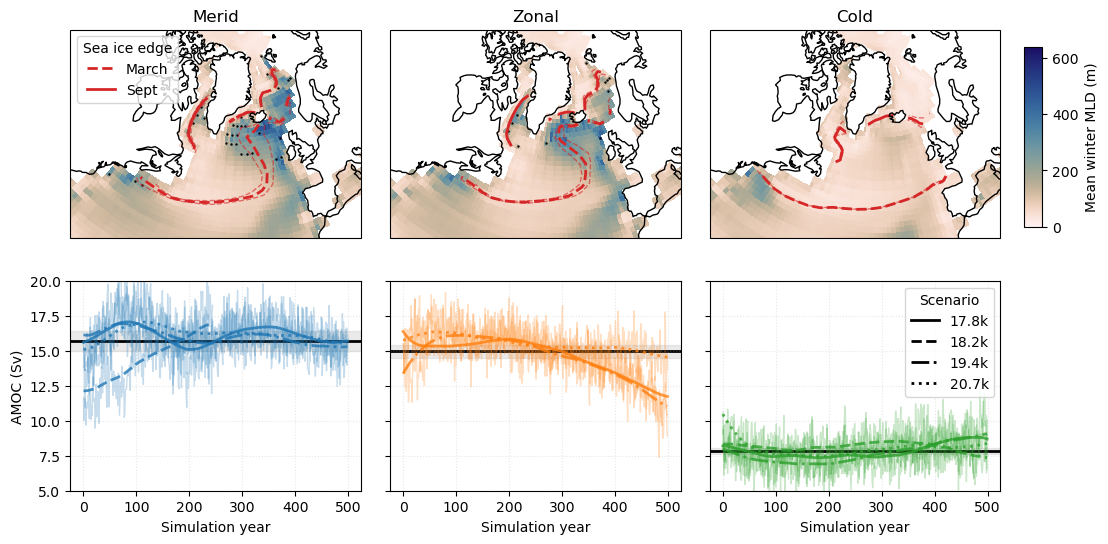

In [31]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D


# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

modes = ["merid", "zonal", "cold"]

scenarios =  {'17.8k','18.2k','19.4k','20.7k'}

scenario_styles = {
    "17.8k": "-",
    "18.2k": "--",
    "19.4k": "-.",
    "20.7k": ":",
}

mode_colors = {
    "merid": "tab:blue",
    "zonal": "tab:orange",
    "cold": "tab:green",
}


projection = ccrs.NorthPolarStereo(central_longitude=-30)

# choose threshold for stippling
mld_std_threshold = 50.0   # metres

# grid for stippling
stipple_stride = 2

cmap=cmc.lapaz_r

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------

fig = plt.figure(figsize=(12,6))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1,1],
    wspace=0.1,
    hspace=0.2
)


# map axes
ax_map = [
    fig.add_subplot(gs[0,i], projection=projection)
    for i in range(3)
]

# time series axes
ax_ts = [
    fig.add_subplot(gs[1,i])
    for i in range(3)
]


# --------------------------------------------------
# TOP ROW: MEAN MLD MAP + STD STIPPLING
# --------------------------------------------------

norm = Normalize(vmin=0,vmax=640)

im = None

for i,mode in enumerate(modes):

    ax = ax_map[i]

    ax.set_extent(
        [-85,5,35,90],
        crs=ccrs.PlateCarree()
    )

    ax.coastlines(zorder=10)

    # land
    #ax.add_feature(
    #    cfeature.LAND,
    #    facecolor="lightgrey",
    #    zorder=1
    #)


    # -------------------------
    # Mean MLD
    # -------------------------

    pcm = ax.pcolormesh(
        mld_stats[mode]["mean"].longitude,
        mld_stats[mode]["mean"].latitude,
        xr.where(
            mld_stats[mode]["mean"] == 0,
            np.nan,
            mld_stats[mode]["mean"],
        ),
        cmap=cmap,
        norm=norm,
        shading="nearest",
        transform=ccrs.PlateCarree(),
        zorder=1,
    )

    # -------------------------
    # MLD stippling
    # -------------------------
    lon = mld_stats[mode]["mean"].longitude,
    lat = mld_stats[mode]["mean"].latitude

    std = mld_stats[mode]["std"]
    
    mask = std > mld_std_threshold

    xx, yy = np.meshgrid(
        lon,
        lat,
    )

    ax.scatter(
        xx[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        yy[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        s=2,
        color="k",
        marker=".",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

    # -------------------------
    # March sea ice
    # -------------------------

    march_mean = seaice_stats[mode]["march"]["mean"]
    march_std = seaice_stats[mode]["march"]["std"]

    lon_si = seaice_stats[mode]["sept"]["mean"].longitude
    lat_si = seaice_stats[mode]["sept"]["mean"].latitude

    ax.contour(
        lon_si,
        lat_si,
        march_mean,
        levels=[0.5],
        colors="tab:red",
        linestyles="--",
        linewidths=2,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    ax.contour(
        lon_si,
        lat_si,
        march_mean + march_std,
        levels=[0.5],
        colors="tab:red",
        linewidths=1,
        linestyles="--",
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    ax.contour(
        lon_si,
        lat_si,
        march_mean - march_std,
        levels=[0.5],
        colors="tab:red",
        linewidths=1,
        linestyles="--",
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    # -------------------------
    # September sea ice
    # -------------------------

    sept_mean = seaice_stats[mode]["sept"]["mean"]
    sept_std = seaice_stats[mode]["sept"]["std"]

    


    ax.contour(
        lon_si,
        lat_si,
        sept_mean,
        levels=[0.5],
        colors="tab:red",
        linewidths=2,
        linestyles="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    ax.contour(
        lon_si,
        lat_si,
        sept_mean + sept_std,
        levels=[0.5],
        colors="tab:red",
        linewidths=1,
        linestyles="--",
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    ax.contour(
        lon_si,
        lat_si,
        sept_mean - sept_std,
        levels=[0.5],
        colors="tab:red",
        linewidths=1,
        linestyles="--",
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    ax.set_title(mode.capitalize())


# colorbar
cax = fig.add_axes([0.92,0.55,0.015,0.3])

cb = fig.colorbar(
    pcm,
    cax=cax
)

cb.set_label(
    "Mean winter MLD (m)"
)



# --------------------------------------------------
# BOTTOM ROW: AMOC TIME SERIES
# --------------------------------------------------

for i,mode in enumerate(modes):

    ax = ax_ts[i]

    # --------------------------------------------------
    # LOOP OVER MODES
    # --------------------------------------------------

#for ax, mode in zip(axes, modes):

    color = mode_colors[mode]

    # -----------------------------------------
    # Ensemble mean/std over ALL experiments
    # -----------------------------------------

    #mean_amoc = float(
    #    amoc_stats[mode]["raw"]["mean"].mean()
    #)

    #std_amoc = float(
    #    amoc_stats[mode]["raw"]["mean"].std()
    #)

    mean_amoc = amoc_stats[mode]["ensemble summary"]['mean']
    std_amoc = amoc_stats[mode]["ensemble summary"]['std']


    # mean line
    ax.axhline(
        mean_amoc,
        color="k",
        lw=2,
        zorder=1,
    )

    # ±1 std
    ax.axhspan(
        mean_amoc - std_amoc,
        mean_amoc + std_amoc,
        color="0.8",
        alpha=0.4,
        zorder=0,
    )

    # -----------------------------------------
    # Plot each scenario
    # -----------------------------------------

    for scenario in scenarios:

        if scenario not in EXPERIMENTS[mode]:
            continue

        exp = EXPERIMENTS[mode][scenario]["exp"]

        if exp not in amoc_lookup[mode]:
            continue

        raw = amoc_lookup[mode][exp]["raw"]
        filt = amoc_lookup[mode][exp]["filtered"]

        x = np.arange(raw.size)

        # raw (faint)
        ax.plot(
            x,
            raw,
            color=color,
            alpha=0.25,
            lw=1,
        )

        # filtered
        ax.plot(
            x,
            filt,
            color=color,
            linestyle=scenario_styles[scenario],
            lw=2,
            label=scenario,
            alpha=0.8
        )

    # -----------------------------------------
    # Formatting
    # -----------------------------------------

    #ax.set_title(mode.capitalize())

    ax.set_ylim(5, 20)

    ax.grid(
        alpha=0.3,
        linestyle=":"
    )

    ax.set_xlabel("Simulation year")


ax_ts[0].set_ylabel("AMOC (Sv)")

for ax in ax_ts[1:]:
    ax.set_yticklabels([])



# --------------------------------------------------
# LEGENDS
# --------------------------------------------------

# --------------------------------------------------
# LEGENDS
# --------------------------------------------------

# Sea ice edge legend (top panel, left)
seaice_handles = [
    Line2D(
        [],
        [],
        color="tab:red",
        lw=2,
        ls="--",
        label="March"
    ),
    Line2D(
        [],
        [],
        color="tab:red",
        lw=2,
        ls="-",
        label="Sept"
    ),
    #Line2D(
    #    [],
    #    [],
    #    color="tab:red",
    #    lw=1,
    #    ls="--",
    #    alpha=0.6,
    #    label="±1 std"
    #),
]

fig.legend(
    handles=seaice_handles,
    loc="upper left",
    bbox_to_anchor=(0.125, 0.88),
    frameon=True,
    title="Sea ice edge",
)


# Scenario legend (bottom row, right)
scenario_handles = [
    Line2D(
        [],
        [],
        color="black",
        linestyle=style,
        lw=2,
        label=scen
    )
    for scen, style in scenario_styles.items()
]

fig.legend(
    handles=scenario_handles,
    loc="upper left",
    bbox_to_anchor=(0.815, 0.46),
    frameon=True,
    title="Scenario",
)


#plt.tight_layout(rect=[0,0,1,1])

#plt.tight_layout(rect=[0,0.05,0.9,1])

#plt.show()

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig1_Rev_AMOCmodes.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)



In [27]:
# Plot A: the discharge timeseries
ds_discharge = xr.open_dataset(f"{data_folder}/mw_inputs/xoup.wfix.glac_ts.nc",decode_times=False)
ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
ds_wfix = xr.open_dataset(f"{data_folder}/lgm_inputs/qrparm.waterfix.hadcm3.nc")

flux = plotting.create_discharge_ts(ds_discharge, ds_lsm, rmean=None,units="kg/m2/s")
t = ds_discharge.t.values

flux_elwg = flux['elwg']
flux_gin = flux['gin']
flux_arc = flux['arc']

__ Creating discharge time series


In [28]:
## Create dataframe

# Create a DataFrame with 't' and the fluxregions
df = pd.DataFrame({
    't': ds_discharge.t,
    'elwg': flux_elwg.value,
    'gin': flux_gin.value,
    'arc': flux_arc.value,
    'tot': flux['tot'].value
})

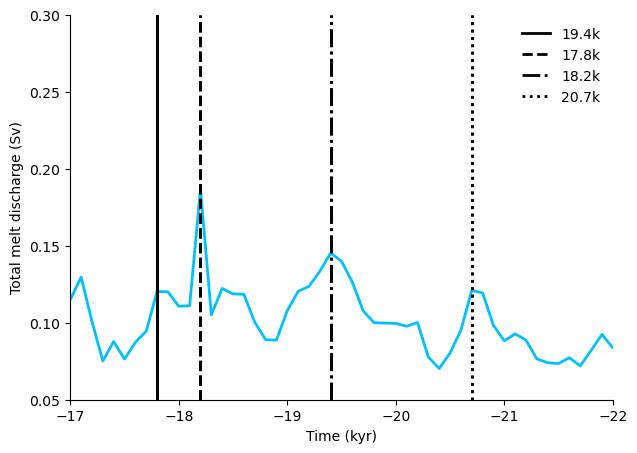

In [29]:
# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df["t"]/1000, df["tot"], color="deepskyblue", linewidth=2)

# Interpolation times (the ones you want to mark)
highlight_times = np.array([-17800, -18200, -19400, -20700])

# Interpolate values at those times
interpolated_values = np.interp(highlight_times, df["t"], df["tot"])

# 🔹 Vertical snapshot lines with different styles
line_styles = ["-", "--", "-.", ":"]

for t, ls in zip(highlight_times, line_styles):
    ax.axvline(x=t/1000, color="black", linestyle=ls, linewidth=2)

# Reversed x-axis ⏪
ax.set_xlim(-17, -22)
ax.set_ylim(0.05, 0.3)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

# Labels
labels = scenarios
for t, ls, lab in zip(highlight_times, line_styles, labels):
    ax.axvline(x=t/1000, color="black", linestyle=ls, linewidth=2, label=lab)

ax.legend(frameon=False)

ax.set_xlabel("Time (kyr)")
ax.set_ylabel("Total melt discharge (Sv)")

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig1_Rev_VarianteDischarge.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)



In [6]:
# Legacy
#Load Sea ice
exp_list = ['xpraj','xprak','xpral'] # 17.8k 

ds_sicec = {}
ds_siced = {}
ds_sicec_spans = {}

for expt in exp_list:
    with mf.Timer(f"{expt} sea ice"):
        ds_sicec[expt] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{expt}/time_series/{expt}.iceconc.monthly.nc')
        
        
        #ds_siced[expt] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{expt}/time_series/{expt}.icedepth.monthly.nc')
        #ds_bstream = xr.open_dataset('/nfs/annie/earpal/database/experiments/tfgbj/time_series/tfgbj.streamFnpf01.monthly.nc')

        ds_sicec_spans[expt] = ds_sicec[expt].groupby("t.month").mean("t")
        ds_sicec_spans[expt]['iceconc_march'] = ds_sicec_spans[expt]['iceconc_mm_srf'].sel(month=3).isel(surface=0)
        ds_sicec_spans[expt]['iceconc_sept'].sel(month=9).isel(surface=0)



[xpraj sea ice]
Elapsed: 5.538286209106445
[xprak sea ice]
Elapsed: 6.921515464782715
[xpral sea ice]
Elapsed: 7.285478353500366
